# DSBDA Practical A-8: Data Visualization I

1. Use the inbuilt dataset 'titanic'. The dataset contains 891 rows and contains information about the passengers who boarded the unfortunate Titanic ship. Use the Seaborn library to see if we can find any patterns in the data.
2. Write a code to check how the price of the ticket (column name: 'fare') for each passenger is distributed by plotting a histogram.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = sns.load_dataset("titanic")

# Display basic info and first few rows
display(df.head())
df.info()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Correlation Matrix
Displaying Correlation Matrix to understand impact of numeric features on survival status.

In [2]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()
display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### Survival Patterns Analysis

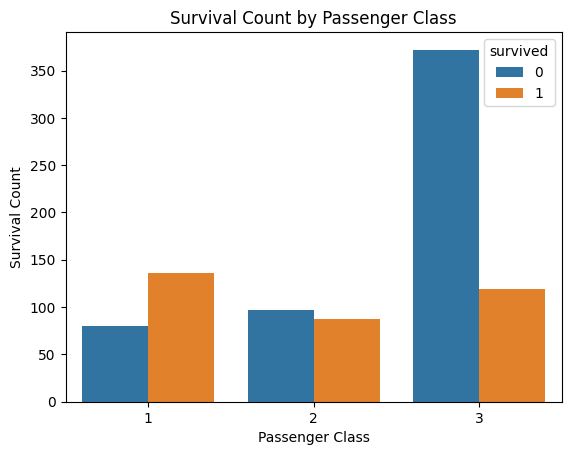

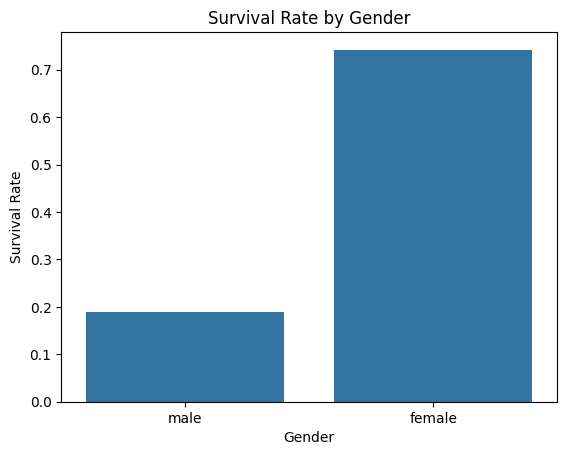

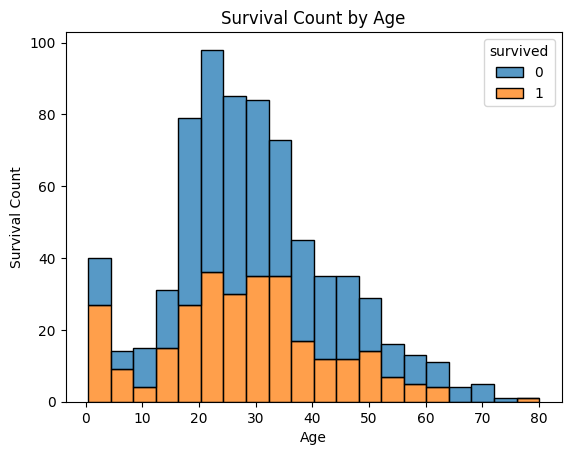

In [3]:
# 1. Survival Count by Passenger Class
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Count')
plt.show()

# Analysis: Higher-class passengers had a better chance of survival.

# 2. Survival Rate by Gender
sns.barplot(x="sex", y="survived", data=df, errorbar=None)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

# Analysis: Females had much higher survival rates than males.

# 3. Survival Count by Age
sns.histplot(x='age', hue='survived', data=df, multiple="stack")
plt.title('Survival Count by Age')
plt.xlabel('Age')
plt.ylabel('Survival Count')
plt.show()

# Analysis: More children survived; older passengers had lower rates.

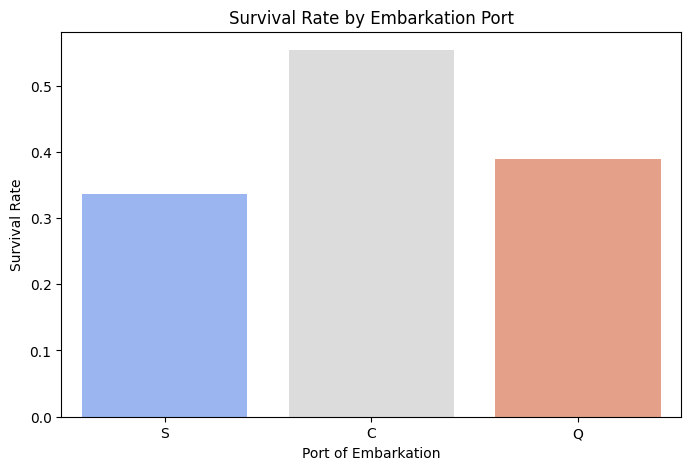

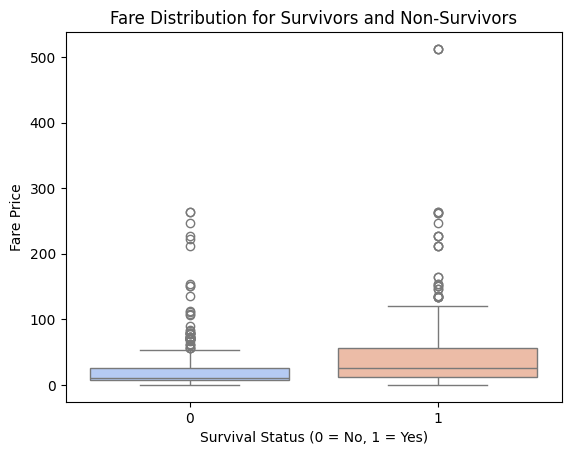

In [4]:
# 4. Survival Rate by Embarkation Port
plt.figure(figsize=(8, 5))
sns.barplot(x="embarked", y="survived", data=df, hue="embarked", palette="coolwarm", errorbar=None, legend=False)
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate")
plt.show()

# 5. Fare Distribution for Survivors
sns.boxplot(x="survived", y="fare", data=df, hue="survived", palette="coolwarm", legend=False)
plt.title("Fare Distribution for Survivors and Non-Survivors")
plt.xlabel("Survival Status (0 = No, 1 = Yes)")
plt.ylabel("Fare Price")
plt.show()

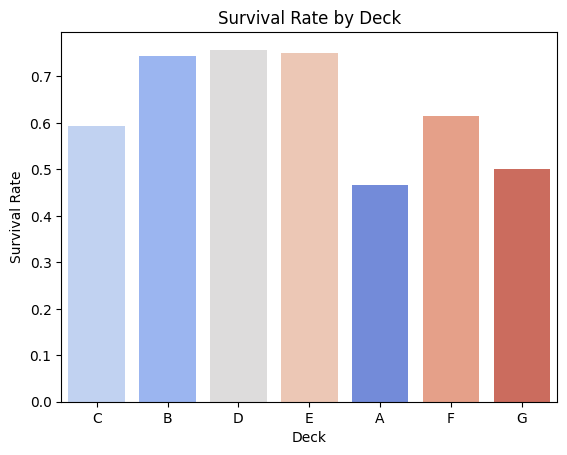

In [5]:
# 6. Survival Rate by Deck
sns.barplot(x="deck", y="survived", data=df, errorbar=None, hue="deck", palette="coolwarm", order=df["deck"].value_counts().index, legend=False)
plt.title("Survival Rate by Deck")
plt.xlabel("Deck")
plt.ylabel("Survival Rate")
plt.show()

### Ticket Price (Fare) Distribution
Histogram of 'fare' distributed by passenger class.

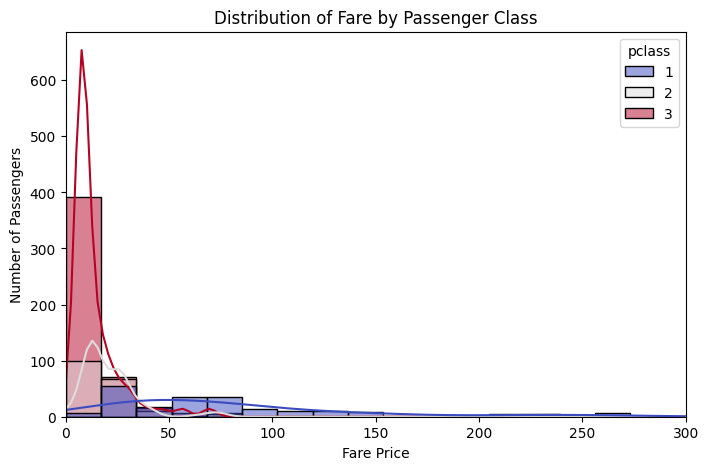

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df, x="fare", hue="pclass", bins=30, kde=True, palette="coolwarm")
plt.title("Distribution of Fare by Passenger Class")
plt.xlabel("Fare Price")
plt.ylabel("Number of Passengers")
plt.xlim(0, 300)
plt.show()

# Practical No: A-9

1. Plot a box plot for distribution of age with respect to each gender along with survival info.
2. Observations and Inferences.

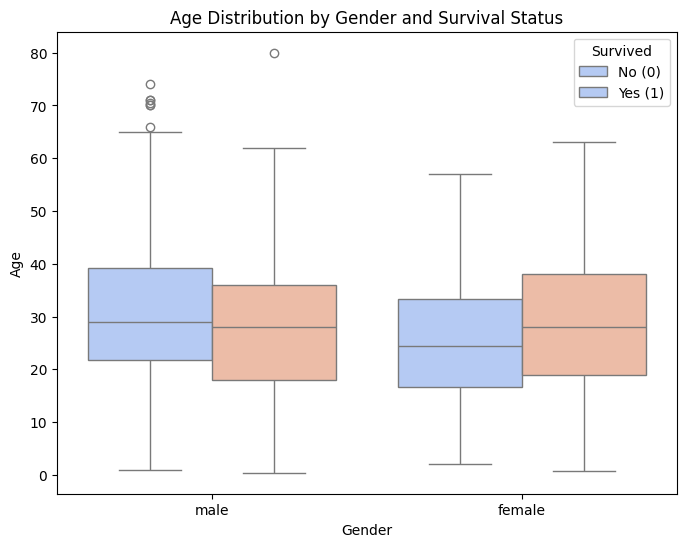

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="sex", y="age", hue="survived", data=df, palette="coolwarm")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.title("Age Distribution by Gender and Survival Status")
plt.legend(title="Survived", labels=["No (0)", "Yes (1)"])
plt.show()

## Detailed Analysis of Visualizations

### 1. Survival by Passenger Class (Count Plot)
*   **Observation**: A significantly higher number of passengers in the 3rd class did not survive compared to the 1st and 2nd classes.
*   **Inference**: Social status was a major factor in survival. 1st-class passengers likely had closer proximity to lifeboats and were prioritized during evacuation.

### 2. Survival Rate by Gender (Bar Plot)
*   **Observation**: The survival rate for females is approximately 74%, while for males it is around 18%.
*   **Inference**: This aligns with the maritime tradition of "women and children first," showing that gender was one of the strongest predictors of survival.

### 3. Survival Count by Age (Histogram/KDE)
*   **Observation**: There is a visible spike in survival for infants and young children (age < 10).
*   **Inference**: Children were given high priority. Conversely, the high density of non-survivors in the 20–40 age range suggests that young and middle-aged adults (particularly men) faced the highest mortality.

### 4. Survival Rate by Embarkation Port (Bar Plot)
*   **Observation**: Passengers who boarded at Cherbourg (C) had a higher survival rate than those from Southampton (S) or Queenstown (Q).
*   **Inference**: This may be because a higher proportion of 1st-class passengers boarded at Cherbourg.

### 5. Fare Distribution for Survivors (Box Plot)
*   **Observation**: The median fare for survivors is notably higher than for non-survivors. There are many high-fare outliers among survivors.
*   **Inference**: Higher ticket prices (linked to better cabins and class) directly correlated with an increased chance of survival.

### 6. Survival Rate by Deck (Bar Plot)
*   **Observation**: Decks B, D, and E show the highest survival rates.
*   **Inference**: These decks were generally located higher up in the ship's structure, providing faster access to the boat deck as the ship sank from the bottom up.

### 7. Fare Distribution by Class (Histogram)
*   **Observation**: The distribution for 3rd class is heavily skewed towards zero, while 1st class is widely distributed with a much higher mean.
*   **Inference**: This confirms the economic disparity between passenger classes and explains why the 'fare' feature acts as a proxy for 'pclass' in survival prediction.

### Observations from the Boxplot:
- **Age Distribution:** Median age is around 30-35 for both genders. IQR ranges roughly from 20 to 40 years.
- **Males:** Non-survivors have a slightly higher median age than survivors. More elderly outliers exist in non-survivors.
- **Females:** Survivors generally belong to a younger age group.
- **Key Inferences:** Females and younger individuals had higher survival rates. Older males had the lowest survival priority.